# Week 2

As explained in in class during Lecture 1, each week of this class is an Jupyter notebook like this one. In order to follow the class, you simply start reading from the top, following the instructions.


### LLM update

<div class="alert alert-block alert-info">
Since we're doing our LLM experiment, I've decided not just to use the blue boxes (like this one), but I have also added comments about how to use (and not to use) the LLMs. <font color="grey">I've put all of those comments in a special grey color - **like the one I'm using here** -  so you can easily spot them</font>.
</div>


## Overview

Today's lecture does a few things.
* First there is an introduction to data visualization incl a little exercise and a video (Part 1). 
* As the main event, we will work with crime-data and generate a large number of interesting and informative plots (Part 2,4,5).
* We will also talk a bit about what makes a good plot (Part 3).

## Part 1: A little visualization exercise

Start by downloading these four datasets: [Data 1](https://raw.githubusercontent.com/suneman/socialdata2023/main/files/data1.tsv), [Data 2](https://raw.githubusercontent.com/suneman/socialdata2023/main/files/data2.tsv), [Data 3](https://raw.githubusercontent.com/suneman/socialdata2023/main/files/data3.tsv), and [Data 4](https://raw.githubusercontent.com/suneman/socialdata2023/main/files/data4.tsv). The format is `.tsv`, which stands for _tab separated values_. 
As you will later realize, these are famous datasets!
Each file has two columns (separated using the tab character). The first column is $x$-values, and the second column is $y$-values.  

It's ok to just download these files to disk by right-clicking on each one, but if you use Python and `urllib` or `urllib2` to get them, I'll really be impressed. <font color='grey'>If you don't know how to do that, you may ask your favorite LLM to explain how they work.</font> You can also go "the old way" and use _stackoverflow_. And by the way, never search stack overflow: search Google and choose the relevant stackoverflow topic.

Now, to the exercise:

> *Exercise*: 
> 
> * Using the `numpy` function `mean`, calculate the mean of both $x$-values and $y$-values for each dataset. 
>      * Use python string formatting to print precisely two decimal places of these results to the output cell. Check out [this _stackoverflow_ page](http://stackoverflow.com/questions/8885663/how-to-format-a-floating-number-to-fixed-width-in-python) for help with the string formatting. <font color='grey'>You may also ask an LLM about the string formatting, but make sure it doesn't just give you the answer: Ask how string formatting works, get some examples, and solve your own problem based on that.</font>
> * Now calculate the variance for all of the various sets of $x$- and $y$-values, by using the `numpy` function `var`. <font color='grey'>You should be able to do this without any help from LLMs.</font> Print it to three decimal places.
> * Use `numpy` to calculate the [Pearson correlation](https://en.wikipedia.org/wiki/Pearson_product-moment_correlation_coefficient) between $x$- and $y$-values for all four data sets (also print to three decimal places).
> * The next step is use _linear regression_ to fit a straight line $f(x) = a x + b$ through each dataset and report $a$ and $b$ (to two decimal places). An easy way to fit a straight line in Python is using `scipy`'s `linregress`. It works like this
> ```
> from scipy import stats
> a, b, r_value, p_value, std_err = stats.linregress(x,y)
>```
> * Comment on the results from the previous steps. What do you observe? 
> * Finally, it's time to plot the four datasets using `matplotlib.pyplot`. Use a two-by-two [`subplot`](http://matplotlib.org/examples/pylab_examples/subplot_demo.html) to put all of the plots nicely in a grid and use the same $x$ and $y$ range for all four plots. And include the linear fit in all four plots. (To get a sense of what I think the plot should look like, you can take a look at my version [here](https://raw.githubusercontent.com/suneman/socialdata2023/main/files/anscombe.png).) <font color='grey'>For this sub-exercise, try to write the code based on the example I link to. If you get stuck, you may use your LLM to figure it out. But don't ask it for the solution, ask for help with figuring out how to use the functions!</font>
> * Explain - in your own words - what you think my point with this exercise is (see below for tips on this). <font color='grey'>Again, try to write down your own thoughts first. Then you can ask your LLM for help after that</font>.
> * <font color='grey'>What did you get out of asking the LLM about the previous sub-question? How did you even go about asking the LLM about the point of the entire set of questions? Reflect on whether or not the LLM helped you get smarter?</font>


Get more insight in the ideas behind this exercise by reading [here](https://en.wikipedia.org/wiki/Anscombe%27s_quartet). Here you can also get an explanation of why the datasets are actually famous - I mean they have their own Wikipedia page!! <font color='grey'>After reading the wikipedia page, can you learn something from a LLM that's not in the wikipedia page?</font>

<div class="alert alert-block alert-info">
All of the important LLM comments are in gray above.
</div>

Now that you get a better sense of why data visualization is an important and powerful tool, you are ready to get a small intro on the topic! Again, don't watch the video until **after** you've done exercise 1.1 

In [2]:
import numpy as np  
import urllib.request
from scipy import stats
import matplotlib.pyplot as plt
from scipy.stats import linregress
import pandas as pd 

In [8]:
datasets = {
  "dataset_1": "https://raw.githubusercontent.com/suneman/socialdata2023/main/files/data1.tsv",
  "dataset_2": "https://raw.githubusercontent.com/suneman/socialdata2023/main/files/data2.tsv",
  "dataset_3": "https://raw.githubusercontent.com/suneman/socialdata2023/main/files/data3.tsv",
  "dataset_4":"https://raw.githubusercontent.com/suneman/socialdata2023/main/files/data4.tsv"
}


In [11]:
path = "/Users/Thomas/Desktop/Skole/Business Analytics/Social data analysis and visualization"

In [13]:
for filename, url in datasets.items():
  file_path = f"{path}/{filename}.tsv"
  urllib.request.urlretrieve(url,file_path)

## Part 1

* Using the `numpy` function `mean`, calculate the mean of both $x$-values and $y$-values for each dataset. 


In [39]:
files = {
  "file1": "/Users/Thomas/Desktop/Skole/Business Analytics/Social data analysis and visualization/dataset_1.tsv",
  "file2": "/Users/Thomas/Desktop/Skole/Business Analytics/Social data analysis and visualization/dataset_2.tsv",
  "file3": "/Users/Thomas/Desktop/Skole/Business Analytics/Social data analysis and visualization/dataset_3.tsv",
  "file4": "/Users/Thomas/Desktop/Skole/Business Analytics/Social data analysis and visualization/dataset_4.tsv"
}

In [41]:
def get_means(files):
  all_means = {}
  
  for i, value in files.items():
    data = np.loadtxt(value,delimiter="\t")
    x_mean = np.mean(data[:, 0])  
    y_mean = np.mean(data[:, 1])  
    all_means[i] = {"x_mean": x_mean, "y_mean": y_mean}
  return all_means  

In [43]:
means = get_means(files)
for i, value in means.items():
  print(f"{i}: x_mean = {value['x_mean']:.2f}, y_mean = {value['y_mean']:.2f}")

file1: x_mean = 9.00, y_mean = 7.50
file2: x_mean = 9.00, y_mean = 7.50
file3: x_mean = 9.00, y_mean = 7.50
file4: x_mean = 9.00, y_mean = 7.50


In [44]:
def get_var(files):
  all_var = {}
  
  for i, value in files.items():
    data = np.loadtxt(value,delimiter="\t")
    x_var = np.var(data[:, 0])  
    y_var = np.var(data[:, 1])  
    all_var[i] = {"x_var": x_var, "y_var": y_var}
  return all_var

In [45]:
variances = get_var(files)
for i, value in variances.items():
  print(f"{i}: x_var = {value['x_var']:.2f}, y_var = {value['y_var']:.2f}")

file1: x_var = 10.00, y_var = 3.75
file2: x_var = 10.00, y_var = 3.75
file3: x_var = 10.00, y_var = 3.75
file4: x_var = 10.00, y_var = 3.75


### Pearson correlation 

In [ ]:
def get_pearson_correlation(files):
    results = {}
    
    for i, value in files.items():
        # Load data
        data = np.loadtxt(value, delimiter="\t")
        
        # Variance
        x_var = np.var(data[:, 0])  # Variance of x
        y_var = np.var(data[:, 1])  # Variance of y
        
        # Pearson correlation
        pearson_corr = np.corrcoef(data[:, 0], data[:, 1])[0, 1]
        
        # Store results
        results[i] = {
            "x_var": round(x_var, 3),
            "y_var": round(y_var, 3),
            "pearson_corr": round(pearson_corr, 3)
        }
    
    return results


In [49]:
results  = get_pearson_correlation(files)
for file, stats in results.items():
    print(f"{file}: x_var = {stats['x_var']}, y_var = {stats['y_var']}, Pearson Correlation = {stats['pearson_corr']}")

file1: x_var = 10.0, y_var = 3.752, Pearson Correlation = 0.816
file2: x_var = 10.0, y_var = 3.752, Pearson Correlation = 0.816
file3: x_var = 10.0, y_var = 3.748, Pearson Correlation = 0.816
file4: x_var = 10.0, y_var = 3.748, Pearson Correlation = 0.817


### Linear regression 

In [56]:
def linear_regression(files):
    regression_results = {}

    for name, file_path in files.items():
        # Load the dataset
        data = np.loadtxt(file_path, delimiter="\t")
        x = data[:, 0]  # First column (x-values)
        y = data[:, 1]  # Second column (y-values)

        # Perform linear regression
        a, b, r_value, p_value, std_err = stats.linregress(x, y)

        # Store the slope and intercept
        regression_results[name] = {
            "slope (a)": round(a, 2),
            "intercept (b)": round(b, 2)
        }

    return regression_results

In [52]:

lin_results = linear_regression(files)

# Print the results
for file, params in lin_results.items():
    print(f"{file}: slope (a) = {params['slope (a)']}, intercept (b) = {params['intercept (b)']}")

file1: slope (a) = 0.5, intercept (b) = 3.0
file2: slope (a) = 0.5, intercept (b) = 3.0
file3: slope (a) = 0.5, intercept (b) = 3.0
file4: slope (a) = 0.5, intercept (b) = 3.0


In [73]:
def plot_linear_regression(files):
    # Set up a 2x2 subplot
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    fig.subplots_adjust(hspace=0.4, wspace=0.3)

    # Ensure the same x and y axis limits for all plots
    x_limits = (0, 20)
    y_limits = (2, 14)

    for ax, (name, path) in zip(axes.flatten(), files.items()):
        # Load the dataset
        data = np.loadtxt(path, delimiter="\t")
        x = data[:, 0]
        y = data[:, 1]

        # Perform linear regression using scipy.stats.linregress
        regression_result = linregress(x, y)
        a = regression_result.slope  # Slope of the line
        b = regression_result.intercept  # Intercept of the line

        # Plot data points
        ax.scatter(x, y, color="black")

        # Plot the regression line
        x_line = np.linspace(*x_limits, 100)
        y_line = a * x_line + b
        ax.plot(x_line, y_line, color="red")

        # Set titles and labels
        ax.set_title(name)
        ax.set_xlim(x_limits)
        ax.set_ylim(y_limits)
        ax.set_xlabel("x")
        ax.set_ylabel("y")

    # Display the plots
    plt.show()

* Comment on the results from the previous steps. What do you observe? 


There is a very little variation in the data and data points is has the same mean. 


* Finally, it's time to plot the four datasets using `matplotlib.pyplot`. Use a two-by-two [`subplot`](http://matplotlib.org/examples/pylab_examples/subplot_demo.html) to put all of the plots nicely in a grid and use the same $x$ and $y$ range for all four plots. And include the linear fit in all four plots

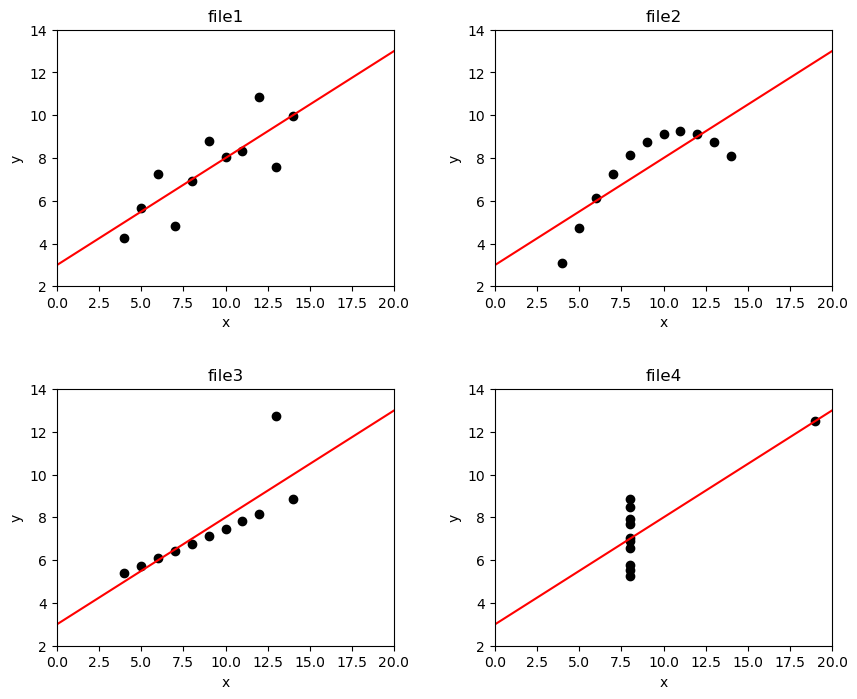

In [74]:
plot_linear_regression(files)

* Explain - in your own words - what you think my point with this exercise is


**My Words**: To understand that visualizing data can tell even more rather than just looking at the numerical values. You assume something but visualizing displays something that you wouldn't be able to see

**LLM words**: This exercise demonstrates the limitations of relying solely on summary statistics and highlights the critical importance of data visualization in analysis. Although all four datasets share nearly identical means, variances, correlations, and regression lines, their visual representations reveal starkly different patterns 

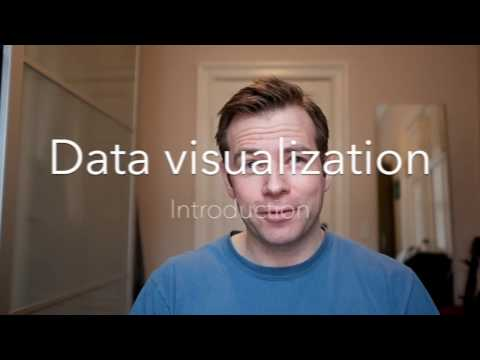

In [2]:
from IPython.display import YouTubeVideo
YouTubeVideo('9D2aI30AMhM', width=800, height=450)

> *Excercise:* Questions for the lecture. 
> 
> * What is the difference between *data* and *metadata*? How does that relate to the GPS tracks-example?
> * Sune says that the human eye is a great tool for data analysis. Do you agree? Explain why/why not. Mention something that the human eye is very good at. Can you think of something that [is difficult for the human eye](http://cdn.ebaumsworld.com/mediaFiles/picture/718392/84732652.jpg). Explain why your example is difficult. 
> * Simpson's paradox is hard to explain. Come up with your own example - or find one on line.
> * In your own words, explain the differnece between *exploratory* and *explanatory* data analysis.
>

<div class="alert alert-block alert-info">
Answer in your own words based on the video, don't use your LLM. Once you've written down your answers, it's OK to use the LLM to get better. It's easy to write a lot with LLMs, but here I want you to keep your answers short and precise.
</div>


What is the difference between *data* and *metadata*? How does that relate to the GPS tracks-example?

- Metadata is the data that is telling us somthing about the data we are working with. Where the data it self is the observed information

Sune says that the human eye is a great tool for data analysis. Do you agree? Explain why/why not. Mention something that the human eye is very good at. Can you think of something that [is difficult for the human eye](http://cdn.ebaumsworld.com/mediaFiles/

- I agree that our eyes is really good for data analysis but at the same time we also need the descriptive statistics and numerical values as a dimension to undertand what is going on in a visiulizaiton. But in first glance our eyes gives a lot of great and fast information. I think our eyes becomes limited when working with darker environments, very dense areas and stuff that that is almost identical. 

 Simpson's paradox is hard to explain. Come up with your own example - or find one on line.

 * 

In your own words, explain the differnece between *exploratory* and *explanatory* data analysis.

*

## Part 2: Visualizing patterns in the data

Visualizing data is a powerful technique that helps us exploiting the human eye, and make complex patterns easier to identify. 

Let's see if we can detect any interesting patterns in the big crime-data file from San Francisco you downloaded last week. We'll again only look at the focus-crimes.

In [75]:
focuscrimes = set(['WEAPON LAWS', 'PROSTITUTION', 'ROBBERY', 'BURGLARY', 'ASSAULT', 'DRUNKENNESS', 'DRUG/NARCOTIC', 'TRESPASS', 'LARCENY/THEFT', 'VANDALISM', 'VEHICLE THEFT', 'STOLEN PROPERTY'])

> *Exercise*: More temporal patterns. Last time we plotted the development over time (how each of the focus crimes changed over time, year-by-year). Today we'll start by looking at the developments across the months, weekdays, and across the 24 hours of the day. 
>
> **Note:** restrict yourself to the dataset of *entire years*.
>
> * *Weekly patterns*. Basically, we'll forget about the yearly variation and just count up what happens during each weekday. [Here's what my version looks like](https://raw.githubusercontent.com/suneman/socialdata2022/main/files/weekdays.png). Some things make sense - for example `drunkenness` and the weekend. But there are some aspects that were surprising to me. Check out `prostitution` and mid-week behavior, for example!?
> * *The months*. We can also check if some months are worse by counting up number of crimes in Jan, Feb, ..., Dec. Did you see any surprises there?
> * *The 24 hour cycle*. We can also forget about weekday and simply count up the number of each crime-type that occurs in the dataset from midnight to 1am, 1am - 2am ... and so on. Again: Give me a couple of comments on what you see. 
> * *Hours of the week*. But by looking at just 24 hours, we may be missing some important trends that can be modulated by week-day, so let's also check out the 168 hours of the week. So let's see the number of each crime-type Monday night from midninght to 1am, Monday night from 1am-2am - all the way to Sunday night from 11pm to midnight.
>
> <font color="grey">It's OK to ask your LLM for help with creating these plots, but</font>
>
> * <font color="grey">Try on your own first,</font>
> * <font color="grey">Then use the LLM ***as a kind of TA*** to help you get your code to work.</font>
>   
> <font color="grey">So don't just ask for answers and pre-written code, then you won't learn how to code & plot in Python - especially the parts about counting the various dates. By actually doing it, you'll start to get a feel for how to slice and dice your dataset according to temporal markers - and that's a key part of data science. You'll be on your way to becoming a true *data whisperer*</font>.

<div class="alert alert-block alert-info">
It's OK to ask your LLM for help with creating these plots, but try on your own first, only after that use the LLM ***as a kind of TA*** to help you get your code to work. Don't just ask for answers and pre-written code, since then you won't learn how to code & plot in Python - especially the parts about counting the various dates. By actually doing it, you'll start to get a feel for how to slice and dice your dataset according to temporal markers - and that's a key part of data science. You'll be on your way to becoming a true data whisperer.
</div>


**Fun little thing**: To further make the point of the exercise in Part 1, check out this video on youtube https://www.youtube.com/watch?v=DbJyPELmhJc  

In [61]:
df_old = pd.read_csv("/Users/Thomas/Desktop/Skole/Business Analytics/Social data analysis and visualization/Police_Department_Incident_Reports__2018_to_Present_20250212.csv", parse_dates=["Incident Date"])
df_new = pd.read_csv("/Users/Thomas/Desktop/Skole/Business Analytics/Social data analysis and visualization/Police_Department_Incident_Reports__Historical_2003_to_May_2018_20250212.csv", parse_dates=["Date"])

pd.set_option('display.max_columns',None)

In [3]:
len(df_old)

930901

In [9]:
df_old.head(5)

,Incident Datetime,Incident Date,Incident Time,Incident Year,Incident Day of Week,Report Datetime,Row ID,Incident ID,Incident Number,CAD Number,Report Type Code,Report Type Description,Filed Online,Incident Code,Incident Category,Incident Subcategory,Incident Description,Resolution,Intersection,CNN,Police District,Analysis Neighborhood,Supervisor District,Supervisor District 2012,Latitude,Longitude,Point,Neighborhoods,ESNCAG - Boundary File,Central Market/Tenderloin Boundary Polygon - Updated,Civic Center Harm Reduction Project Boundary,HSOC Zones as of 2018-06-05,Invest In Neighborhoods (IIN) Areas,Current Supervisor Districts,Current Police Districts
0,2023/03/01 05:02:00 AM,2023/03/01,05:02,2023,Wednesday,2023/03/11 03:40:00 PM,125379506374,1253795,236046151,NaN,II,Coplogic Initial,True,6374,Larceny Theft,Larceny Theft - Other,"Theft, Other Property, >$950",Open or Active,NaN,NaN,Mission,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2023/03/13 10:59:00 AM,2023/03/13,10:59,2023,Monday,2023/03/13 11:00:00 AM,125355107041,1253551,230174885,NaN,VS,Vehicle Supplement,NaN,7041,Recovered Vehicle,Recovered Vehicle,"Vehicle, Recovered, Auto",Open or Active,NaN,NaN,Out of SF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2023/03/14 06:44:00 PM,2023/03/14,18:44,2023,Tuesday,2023/03/14 06:45:00 PM,125402407041,1254024,230176728,NaN,VS,Vehicle Supplement,NaN,7041,Recovered Vehicle,Recovered Vehicle,"Vehicle, Recovered, Auto",Open or Active,NaN,NaN,Out of SF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2023/02/15 03:00:00 AM,2023/02/15,03:00,2023,Wednesday,2023/03/11 04:55:00 PM,125378606372,1253786,236046123,NaN,II,Coplogic Initial,True,6372,Larceny Theft,Larceny Theft - Other,"Theft, Other Property, $50-$200",Open or Active,NaN,NaN,Mission,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2023/03/13 11:26:00 AM,2023/03/13,11:26,2023,Monday,2023/03/13 01:37:00 PM,125419506244,1254195,236046850,NaN,II,Coplogic Initial,True,6244,Larceny Theft,Larceny - From Vehicle,"Theft, From Locked Vehicle, >$950",Open or Active,NaN,NaN,Central,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
df_new.head(5)

,PdId,IncidntNum,Incident Code,Category,Descript,DayOfWeek,Date,Time,PdDistrict,Resolution,Address,X,Y,location,SF Find Neighborhoods 2 2,Current Police Districts 2 2,Current Supervisor Districts 2 2,Analysis Neighborhoods 2 2,DELETE - Fire Prevention Districts 2 2,DELETE - Police Districts 2 2,DELETE - Supervisor Districts 2 2,DELETE - Zip Codes 2 2,DELETE - Neighborhoods 2 2,DELETE - 2017 Fix It Zones 2 2,Civic Center Harm Reduction Project Boundary 2 2,Fix It Zones as of 2017-11-06 2 2,DELETE - HSOC Zones 2 2,Fix It Zones as of 2018-02-07 2 2,"CBD, BID and GBD Boundaries as of 2017 2 2","Areas of Vulnerability, 2016 2 2",Central Market/Tenderloin Boundary 2 2,Central Market/Tenderloin Boundary Polygon - Updated 2 2,HSOC Zones as of 2018-06-05 2 2,OWED Public Spaces 2 2,Neighborhoods 2
0,4133422003074,41334220,3074,ROBBERY,"ROBBERY, BODILY FORCE",Monday,11/22/2004,17:50,INGLESIDE,NONE,GENEVA AV / SANTOS ST,-122.420084,37.708311,POINT (-122.420084075249 37.7083109744362),NaN,NaN,9.0,NaN,NaN,NaN,8.0,309.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,5118535807021,51185358,7021,VEHICLE THEFT,STOLEN AUTOMOBILE,Tuesday,10/18/2005,20:00,PARK,NONE,TURK ST / STJOSEPHS AV,-120.500000,90.000000,POINT (-120.50000000000001 90),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4018830907021,40188309,7021,VEHICLE THEFT,STOLEN AUTOMOBILE,Sunday,02/15/2004,02:00,SOUTHERN,NONE,BRANNAN ST / 1ST ST,-120.500000,90.000000,POINT (-120.50000000000001 90),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,11014543126030,110145431,26030,ARSON,ARSON,Friday,02/18/2011,05:27,INGLESIDE,NONE,0 Block of SANJUAN AV,-122.436220,37.724377,POINT (-122.43622001281001 37.7243766140428),94.0,9.0,1.0,28.0,9.0,7.0,6.0,28861.0,25.0,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,94.0
4,10108108004134,101081080,4134,ASSAULT,BATTERY,Sunday,11/21/2010,17:00,SOUTHERN,NONE,400 Block of 10TH ST,-122.410541,37.770913,POINT (-122.410541166987 37.7709130566165),32.0,1.0,10.0,34.0,8.0,2.0,9.0,28853.0,34.0,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,32.0


In [13]:
# Convert 'Incident Date' to datetime format
df_old["Incident Date"] = pd.to_datetime(df_old["Incident Date"])
df_new["Incident Date"] = pd.to_datetime(df_new["Incident Date"])

# Filter for complete years (keep full 2003-2017 in old dataset, 2018+ in new dataset)
df_old = df_old[df_old["Incident Date"].dt.year < 2018]  
df_new = df_new[df_new["Incident Date"].dt.year >= 2018]  

In [25]:
# Merge the datasets
df_combined = pd.concat([df_old, df_new], ignore_index=True)

# Save the cleaned and merged dataset
df_combined.to_csv("/Users/Thomas/Desktop/Skole/Business Analytics/Social data analysis and visualization/sf_crime_2003_present_cleaned.csv", index=False)

In [42]:
cleaned_df = pd.read_csv("/Users/Thomas/Desktop/Skole/Business Analytics/Social data analysis and visualization/sf_crime_2003_present_cleaned.csv")

In [43]:
cleaned_df.head()

,Incident Date,Incident Time,Incident Day of Week,Incident Category,Incident Description,Police District,Latitude,Longitude
0,2018-01-24,15:46,Wednesday,LARCENY/THEFT,PETTY THEFT OF PROPERTY,PARK,37.768225,-122.445798
1,2018-05-07,10:23,Monday,LARCENY/THEFT,PETTY THEFT SHOPLIFTING,SOUTHERN,37.785977,-122.405359
2,2018-01-06,13:07,Saturday,NON-CRIMINAL,"AIDED CASE, MENTAL DISTURBED",PARK,37.770370,-122.444524
3,2018-05-10,23:50,Thursday,OTHER OFFENSES,RESISTING ARREST,NORTHERN,37.785433,-122.419641
4,2018-01-22,21:05,Monday,VANDALISM,"MALICIOUS MISCHIEF, VANDALISM",CENTRAL,37.786719,-122.413174


In [55]:
# Convert 'Incident Date' to datetime format
cleaned_df["Incident Date"] = pd.to_datetime(cleaned_df["Incident Date"], format="%Y-%m-%d")

# Convert 'Incident Time' to proper time format
cleaned_df["Incident Time"] = pd.to_datetime(cleaned_df["Incident Time"], format="%H:%M", errors="coerce").dt.time



In [3]:
cleaned_df = pd.read_csv("/Users/Thomas/Desktop/Skole/Business Analytics/Social data analysis and visualization/sf_crime_2003_present_cleaned.csv")

In [78]:
cleaned_df.head()

,Incident ID,Incident Number,Incident Code,Incident Category,Incident Description,Incident Day of Week,Incident Date,Incident Time,Police District,Resolution,Intersection,Latitude,Longitude
0,1253795,236046151,6374,Larceny Theft,"Theft, Other Property, >$950",Wednesday,2023-03-01,05:02,Mission,Open or Active,NaN,NaN,NaN
1,1253551,230174885,7041,Recovered Vehicle,"Vehicle, Recovered, Auto",Monday,2023-03-13,10:59,Out of SF,Open or Active,NaN,NaN,NaN
2,1254024,230176728,7041,Recovered Vehicle,"Vehicle, Recovered, Auto",Tuesday,2023-03-14,18:44,Out of SF,Open or Active,NaN,NaN,NaN
3,1253786,236046123,6372,Larceny Theft,"Theft, Other Property, $50-$200",Wednesday,2023-02-15,03:00,Mission,Open or Active,NaN,NaN,NaN
4,1254195,236046850,6244,Larceny Theft,"Theft, From Locked Vehicle, >$950",Monday,2023-03-13,11:26,Central,Open or Active,NaN,NaN,NaN


In [80]:
# Convert 'Incident Date' to datetime format
cleaned_df["Incident Date"] = pd.to_datetime(cleaned_df["Incident Date"], format="%Y-%m-%d")

# Convert 'Incident Time' to proper time format
cleaned_df["Incident Time"] = pd.to_datetime(cleaned_df["Incident Time"], format="%H:%M", errors="coerce").dt.time

In [82]:
cleaned_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3060426 entries, 0 to 3060425
Data columns (total 13 columns):
 #   Column                Dtype         
---  ------                -----         
 0   Incident ID           int64         
 1   Incident Number       int64         
 2   Incident Code         int64         
 3   Incident Category     object        
 4   Incident Description  object        
 5   Incident Day of Week  object        
 6   Incident Date         datetime64[ns]
 7   Incident Time         object        
 8   Police District       object        
 9   Resolution            object        
 10  Intersection          object        
 11  Latitude              float64       
 12  Longitude             float64       
dtypes: datetime64[ns](1), float64(2), int64(3), object(7)
memory usage: 303.5+ MB


# Exercise

In [83]:
focus_crimes = set(['WEAPON LAWS', 'PROSTITUTION', 'ROBBERY', 'BURGLARY', 'ASSAULT', 'DRUNKENNESS', 'DRUG/NARCOTIC', 'TRESPASS', 'LARCENY/THEFT', 'VANDALISM', 'VEHICLE THEFT', 'STOLEN PROPERTY'])

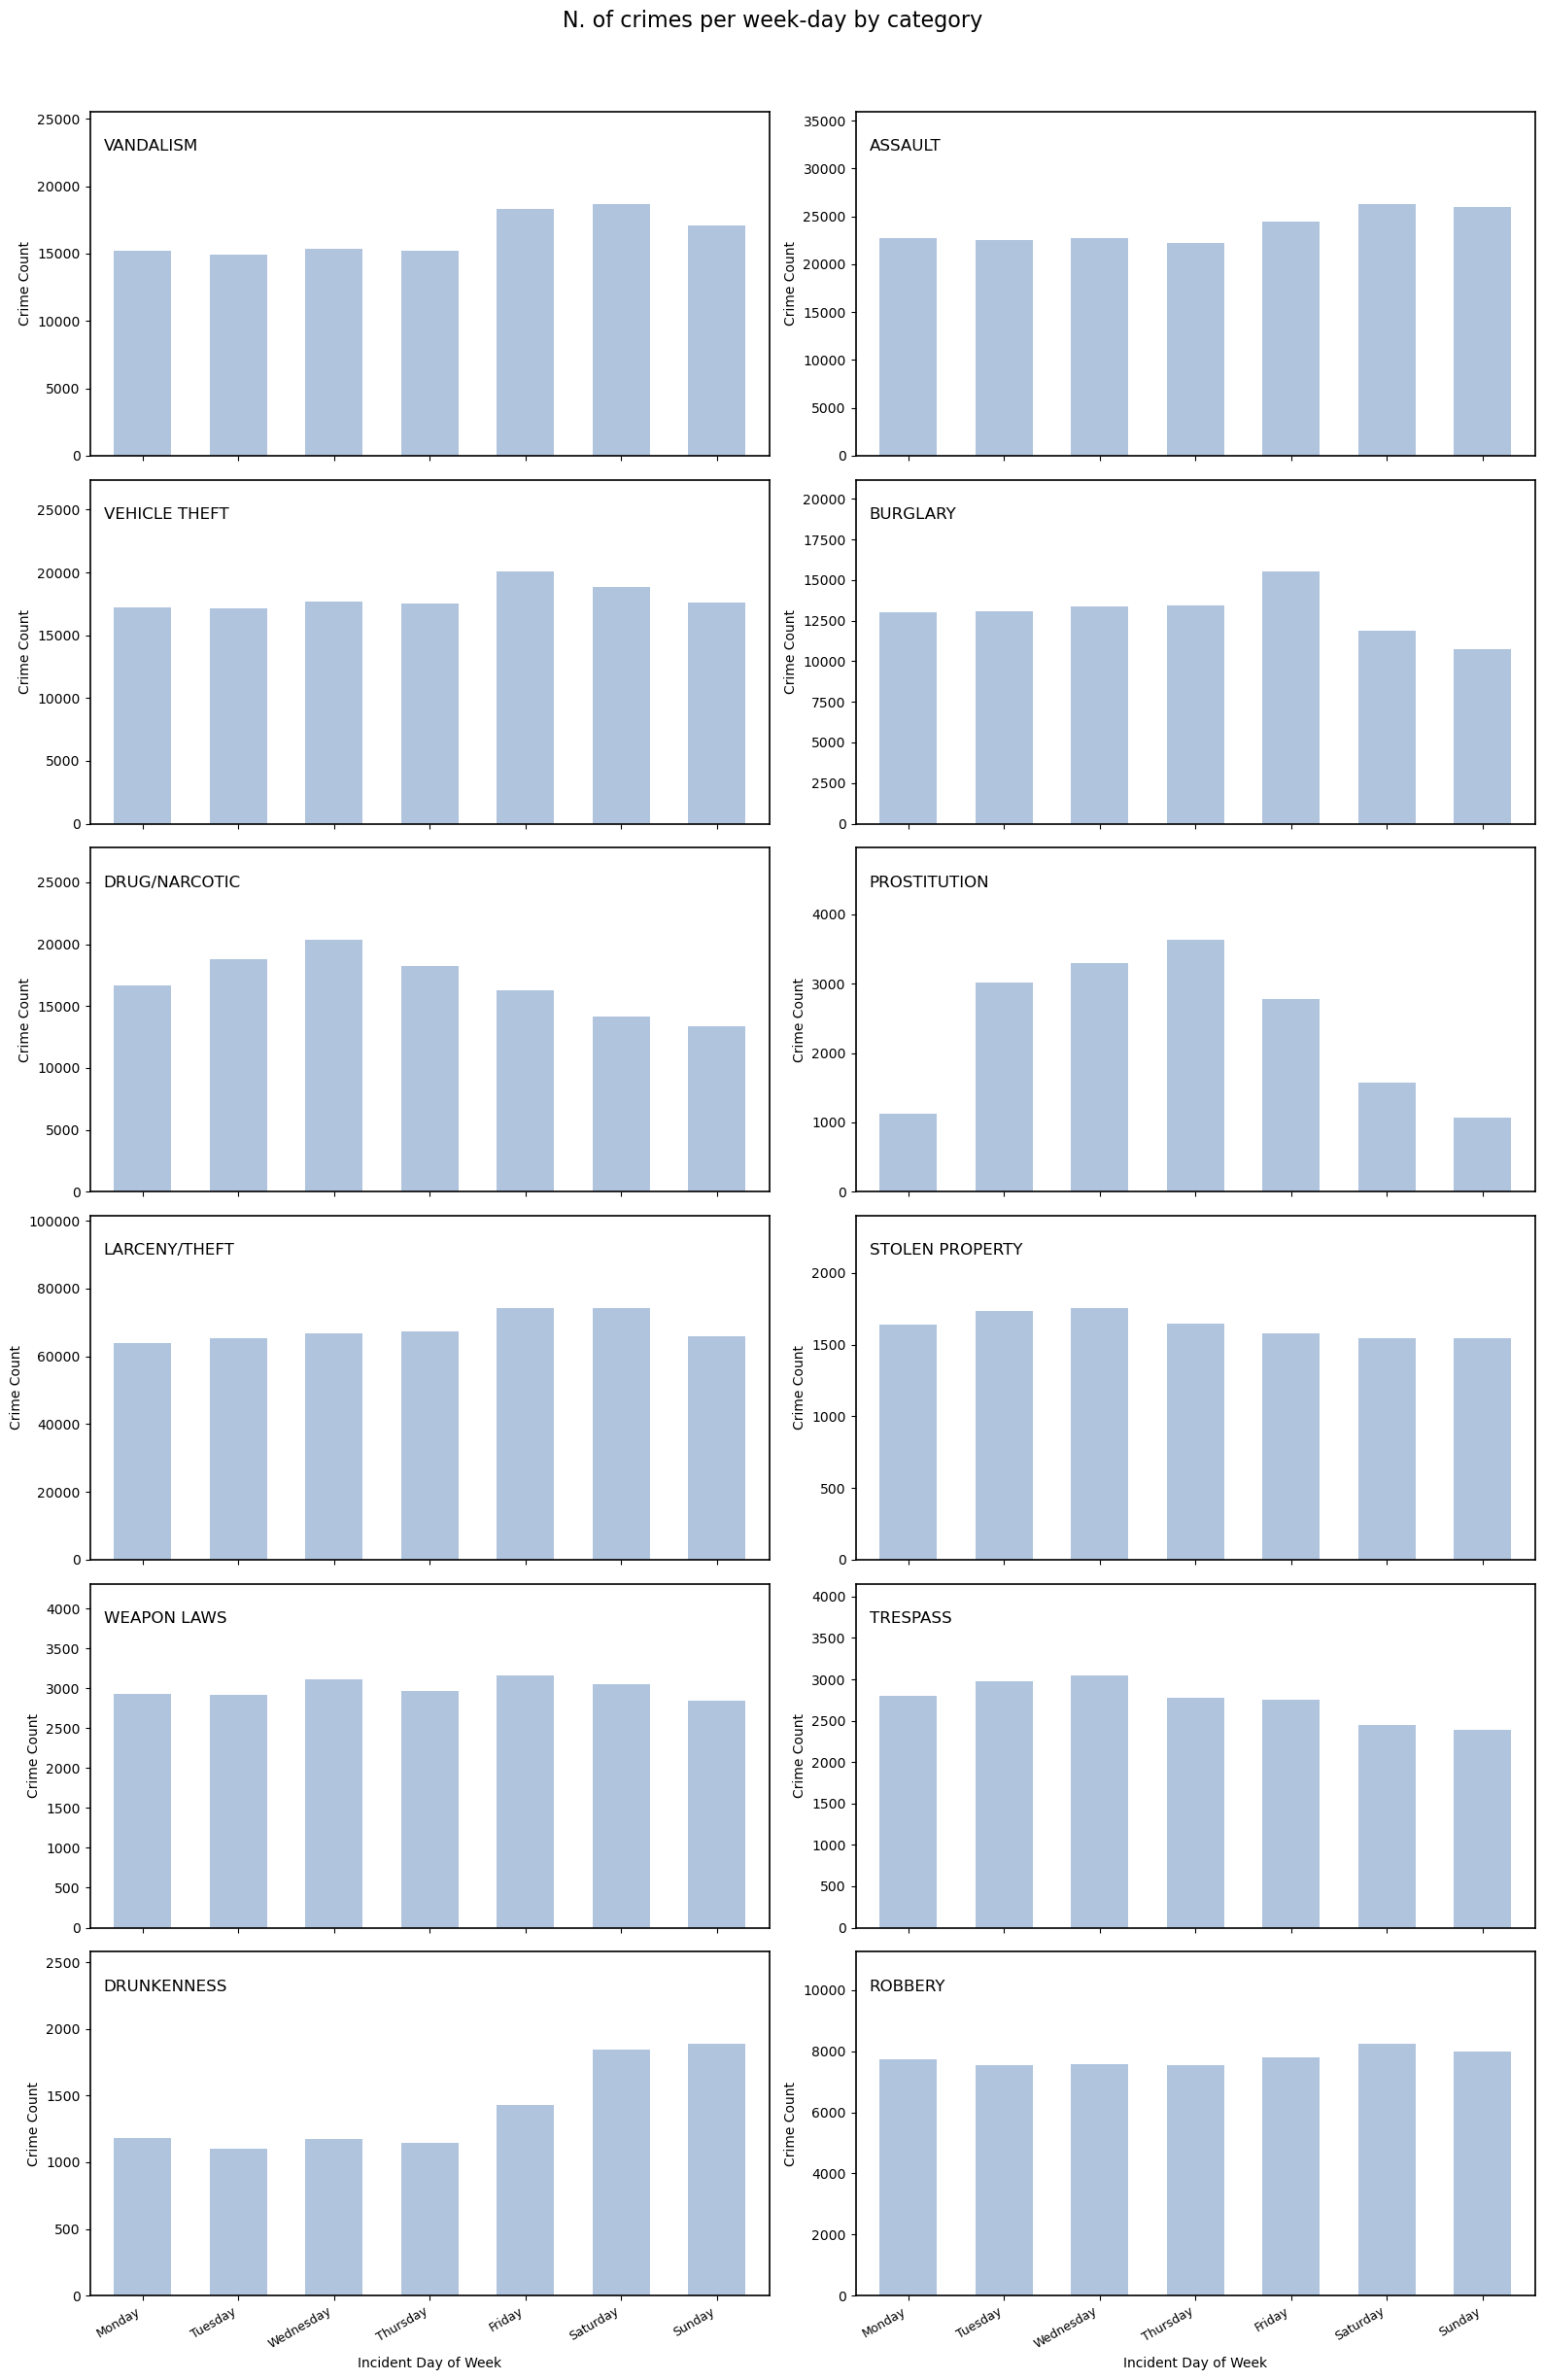

In [ ]:
# Filter dataset for focus crimes
filtered_df = cleaned_df[cleaned_df["Incident Category"].isin(focus_crimes)]

# Count crimes by weekday
weekday_counts = filtered_df.groupby(["Incident Category", "Incident Day of Week"]).size().unstack()

# Define the correct order of weekdays
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday_counts = weekday_counts[weekday_order]

# Create subplots with **larger height** for more space inside each box
fig, axes = plt.subplots(nrows=6, ncols=2, figsize=(16, 26), sharey=False, sharex=True)
axes = axes.flatten()

for ax, crime in zip(axes, focus_crimes):
    if crime in weekday_counts.index:
        # Plot bar chart with **narrower bars**
        weekday_counts.loc[crime].plot(
            kind="bar", ax=ax, color="lightsteelblue", width=0.6
        )
        
        ax.set_ylabel("Crime Count", fontsize=10)  # Slightly smaller labels
        ax.set_xticklabels(weekday_order, rotation=30, ha="right", fontsize=9)


        ymax = ax.get_ylim()[1]  
        ax.set_ylim(0, ymax * 1.3)  # **Extend by 30% to ensure text fits inside**


        ax.text(
            0.02, 0.92, crime, fontsize=12, ha="left", va="top",
            transform=ax.transAxes, fontweight="normal"
        )


        for spine in ax.spines.values():
            spine.set_linewidth(1.2)


for ax in axes[:-2]:  
    ax.set_xlabel("")



fig.suptitle("N. of crimes per week-day by category", fontsize=16, fontweight="normal", y=0.97)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Adjust spacing for **better fit**
plt.show()

# Part 3: Creating nice plots

Ok. There's a lot of barcharts today. We need them ... they are a fantastic tool for data exploration. But it can get monotonous, so let's take a little break to talk about something else before digging deeper with the barcharts.

I want to tell you a bit about how to make nice plots. I do that in the video below

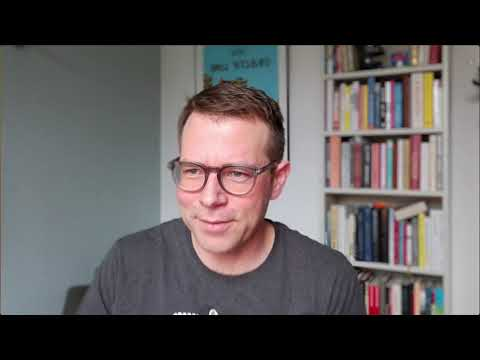

In [4]:
YouTubeVideo('9hIu4pgJXQc', width=800, height=450)

> *Exercise:* Nice plots. 
>
> * Create a list of 10 rules for nice plots based on the video.

<div class="alert alert-block alert-info">
Answer in your own words, do your own research, don't use your LLM. Once you've written down your answers, it's OK to use the LLM to get better.
</div>

1. Make sure that axis is "normalized" or just displays correct range, such that small deviations is not getting displayed as "drastic changes" 
2. Less is better
3. Make sure that subplots has a tight layout without too much whitespacing between them
4. Remember labels and legends! 
5. Think about the zoom level of the plot. Adjust axes
6. Make good captions
7. 
8.
9.
10.

In [2]:
import calplot

# Part 4: Exploring other types of plots for temporal data

We continue our mini-break from barcharts by exploring more ways to plot temporal data.

> *Exercise:* Other cool ways to plot temporal data. I am going to introduce three different plot-types. Then your job is to choose a part of the crime-data that you care about - and plot it using these new ways of visualizing data. <font color="grey">For this one, you may use the full power of your LLM! Yes, I'm serious. Go nuts and see if you can get these plots going by fully relying on code generated by your LLM</font>. In case you want to use the *old ways* (that's of course always OK), I've included links and tips. 
>
>I recommend that you choose a different part of the crime-data for each plot-type.
> * Calendar plots. Get started on calendar plots **[here](https://calplot.readthedocs.io/en/latest/)**. There are other packages for plotting these, those are also OK to use.
> * [Polar bar chart](https://user-images.githubusercontent.com/12328192/89272649-be76e200-d63e-11ea-97ad-fd1ba5831c89.png). Here I want you to plot a 24-hour pattern of some sort -- those work really well in radial plots (another name for polar plots) because the day  wraps around on itself. You can also try plotting data with patterns from the 168 hours of the week. There's not one super-awesome solution here, you can try using [pure matplotlib](https://matplotlib.org/stable/gallery/pie_and_polar_charts/polar_bar.html) ... [some examples here](https://www.python-graph-gallery.com/circular-barplot/) or via [plotly](https://plotly.com/python/polar-chart/) (scroll down a bit for the polar barchart).
> * Time series. Time series is a key functionality of `Pandas`, so here I simply recommend starting by searching your favorite search engine for something like `time series` `pandas`
> * Reflection (<font color="grey">no LLM help here</font>): What did you learn from using LLM's to simply solve everything in this exercise (in contrast to the previous ones).

**Note**: I added this exercise with fewer hints than usual. Normally, I help you break down the problems into small solvable bits. <font color="grey">Since this is a LLM exercise, I haven't done that. But I encourage you to play with figuring out the steps in solving the problem. You can ask the LLM to help you if you like (but perhaps try yourself first and compare to what the LLM suggested).</font> 

This ties in to a bigger picture thing about data science.

*My philosophy for data science is this*: Getting to what you want rarely seems hard once you found your way there, the difficulty comes in breaking down a hard problem into the little steps you need to take to solve your complex problem. In this class, I usually do the breaking down for you and provide you with the steps (that's how you go from nothing to creating complex visualizations of crime-data). But I also want you to learn the breaking-problems-down part. <font color="grey">This is one of the areas where LLMs can be of help -- they excel at breaking down problems into smaller bits -- but if you don't try yourself, you'll never get good at it. So always create your own breakdown first, then see what the computer thinks. Perhaps it can help you get better at it 😀 </font>.

*My approach is always to think*: Even if my task seems impossible, I think: "is there any problem that I ***CAN*** solve that will get me closer to where I want to go?" Once I've solved that part, I'm smarter and I try to think: "Is there a new problem I can solve that'll get me closer knowing what I know now?" And I just keep going. Usually that's enough.

*If that seems too abstract*, a useful goal for you is to use your internet searching skills (old fashioned ones) to figure out how to make each visualization work -- look for examples, tutorials, stack overflow posts, people who have found the same error messages as you, etc, etc. <font color="grey">And of course consulting your LLM</font>.

<div class="alert alert-block alert-info">
Detailed LLM hints in gray in the text itself.
</div>

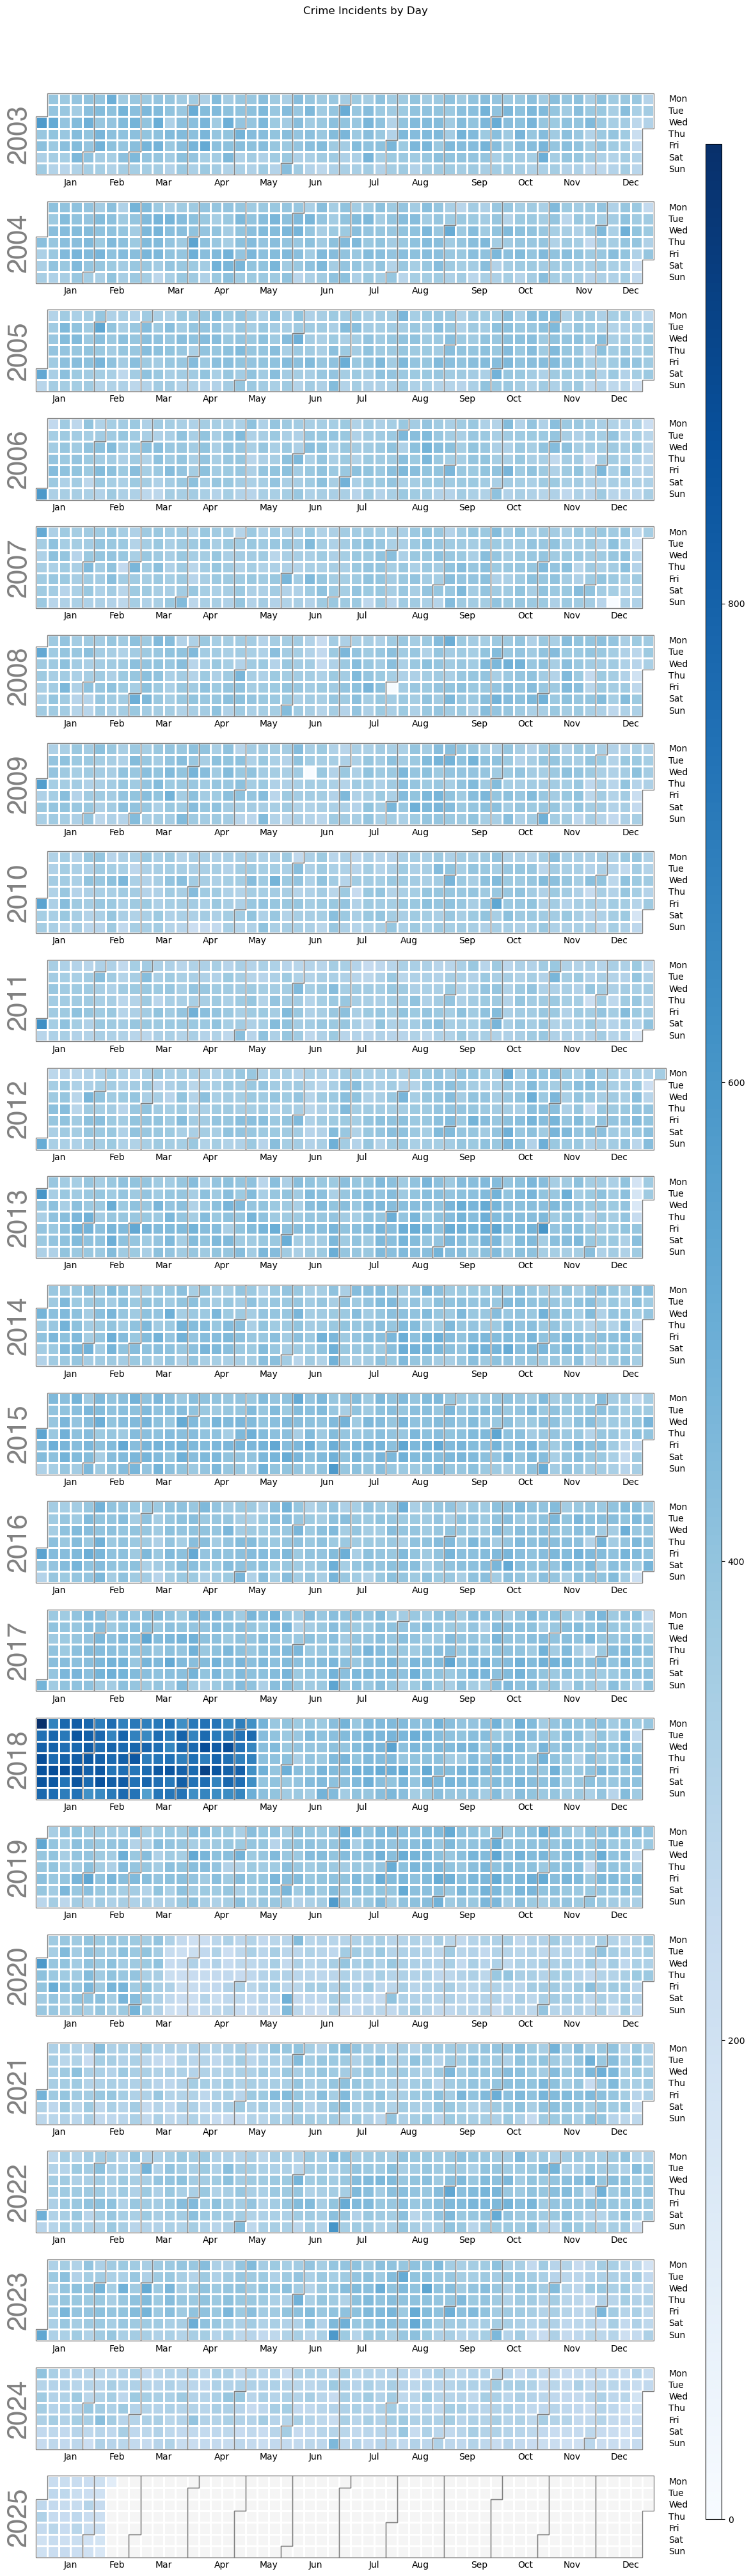

In [115]:
# Aggregate crime counts by date
crime_counts = cleaned_df.groupby("Incident Date").size()

# Generate calendar heatmap
calplot.calplot(crime_counts, cmap="Blues", suptitle="Crime Incidents by Day", colorbar=True)

plt.show()

In [117]:
cleaned_df.head()

,Incident ID,Incident Number,Incident Code,Incident Category,Incident Description,Incident Day of Week,Incident Date,Incident Time,Police District,Resolution,Intersection,Latitude,Longitude
0,1253795,236046151,6374,Larceny Theft,"Theft, Other Property, >$950",Wednesday,2023-03-01,05:02:00,Mission,Open or Active,NaN,NaN,NaN
1,1253551,230174885,7041,Recovered Vehicle,"Vehicle, Recovered, Auto",Monday,2023-03-13,10:59:00,Out of SF,Open or Active,NaN,NaN,NaN
2,1254024,230176728,7041,Recovered Vehicle,"Vehicle, Recovered, Auto",Tuesday,2023-03-14,18:44:00,Out of SF,Open or Active,NaN,NaN,NaN
3,1253786,236046123,6372,Larceny Theft,"Theft, Other Property, $50-$200",Wednesday,2023-02-15,03:00:00,Mission,Open or Active,NaN,NaN,NaN
4,1254195,236046850,6244,Larceny Theft,"Theft, From Locked Vehicle, >$950",Monday,2023-03-13,11:26:00,Central,Open or Active,NaN,NaN,NaN


In [20]:
cleaned_df = pd.read_csv("/Users/Thomas/Desktop/Skole/Business Analytics/Social data analysis and visualization/sf_crime_2003_present_cleaned.csv")

In [21]:
cleaned_df.head()

,Incident ID,Incident Number,Incident Code,Incident Category,Incident Description,Incident Day of Week,Incident Date,Incident Time,Police District,Resolution,Intersection,Latitude,Longitude
0,1253795,236046151,6374,Larceny Theft,"Theft, Other Property, >$950",Wednesday,2023-03-01,05:02,Mission,Open or Active,NaN,NaN,NaN
1,1253551,230174885,7041,Recovered Vehicle,"Vehicle, Recovered, Auto",Monday,2023-03-13,10:59,Out of SF,Open or Active,NaN,NaN,NaN
2,1254024,230176728,7041,Recovered Vehicle,"Vehicle, Recovered, Auto",Tuesday,2023-03-14,18:44,Out of SF,Open or Active,NaN,NaN,NaN
3,1253786,236046123,6372,Larceny Theft,"Theft, Other Property, $50-$200",Wednesday,2023-02-15,03:00,Mission,Open or Active,NaN,NaN,NaN
4,1254195,236046850,6244,Larceny Theft,"Theft, From Locked Vehicle, >$950",Monday,2023-03-13,11:26,Central,Open or Active,NaN,NaN,NaN


In [22]:
# Check the exact column names
print(cleaned_df.columns)

Index(['Incident ID', 'Incident Number', 'Incident Code', 'Incident Category',
       'Incident Description', 'Incident Day of Week', 'Incident Date',
       'Incident Time', 'Police District', 'Resolution', 'Intersection',
       'Latitude', 'Longitude'],
      dtype='object')


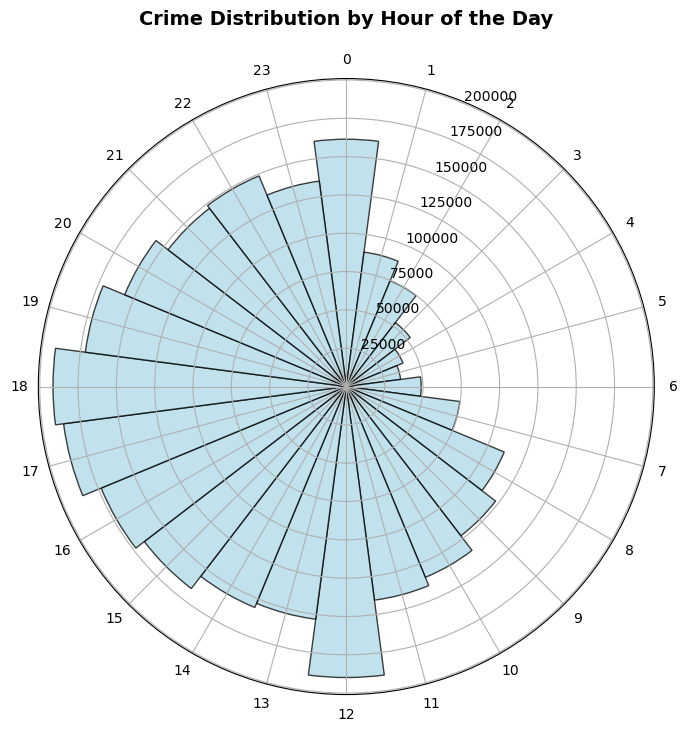

In [4]:
# Ensure 'Incident Time' is in datetime format, extracting only the hour
cleaned_df["Incident Hour"] = pd.to_datetime(cleaned_df["Incident Time"], format="%H:%M").dt.hour

# Count occurrences for each hour (0-23)
hourly_counts = cleaned_df["Incident Hour"].value_counts().reindex(range(24), fill_value=0)

# Convert hour indices to radians for circular plotting
theta = np.linspace(0, 2*np.pi, 24, endpoint=False)  # 24 hours mapped to full circle

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'projection': 'polar'})

# Create polar bar chart with better spacing and width
bars = ax.bar(theta, hourly_counts, width=np.pi/12, color="lightblue", edgecolor="black", alpha=0.75)

# Format plot
ax.set_xticks(theta)
ax.set_xticklabels(range(24))  # Hours from 0 to 23
ax.set_title("Crime Distribution by Hour of the Day", fontsize=14, fontweight="bold", pad=20)

# Ensure the 0-hour (midnight) is at the top
ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)

plt.show()

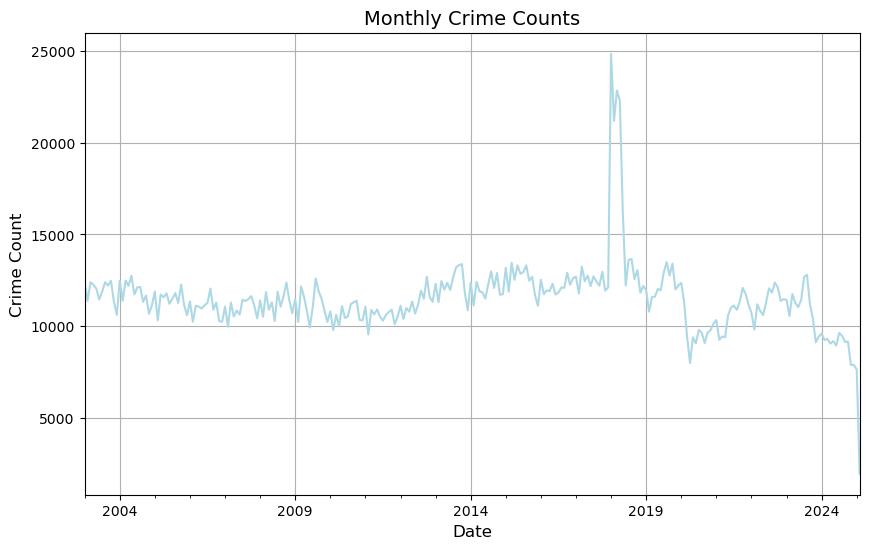

In [23]:
# Ensure that 'Incident Date' is in datetime format
cleaned_df['Incident Date'] = pd.to_datetime(cleaned_df['Incident Date'])

# Set 'Incident Date' as index for time series plotting
cleaned_df.set_index('Incident Date', inplace=True)

# Resample the data by month (you can change it to 'W' for weekly or 'D' for daily)
monthly_crime_counts = cleaned_df.resample('ME').size()

# Plot the time series data without the edgecolor argument
plt.figure(figsize=(10,6))
monthly_crime_counts.plot(kind='line', color='lightblue')  # Removed edgecolor
plt.title("Monthly Crime Counts", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Crime Count", fontsize=12)
plt.grid(True)
plt.show()

# Part 5: Back to visualizing patterns in the data

The next thing we'll be looking into is how crimes break down across the 10 districts in San Francisco. <font color="grey">See if you can do this on your own - the calculations are fairly simple. If you get stuck, you may ask your LLM for advice, but don't use it to simply generate the plots. Use it as a help to get hints at how to solve the things you can't figure out on your own.</font>

> *Exercise*: The types of crime and how they take place across San Francisco's police districts.
>  
>  * So now we'll be combining information about `PdDistrict` and `Category` to explore differences between SF's neighborhoods. First, simply list the names of SF's 10 police districts.
>  * Which has the most crimes? Which has the most focus crimes?
>  * Next, we want to generate a slightly more complicated graphic. I'm interested to know if there are certain crimes that happen much more in certain neighborhoods than what's typical. Below I describe how to get that plot going:
>    - First, we need to calculate the relative probabilities of seeing each type of crime in the dataset as a whole. That's simply a normalized version of [this plot](https://raw.githubusercontent.com/suneman/socialdata2022/main/files/CrimeOccurrencesByCategory.png). Let's call it `P(crime)`.
>    - Next, we calculate that same probability distribution _but for each PD district_, let's call that `P(crime|district)`.
>    - Now we look at the ratio `P(crime|district)/P(crime)`. That ratio is equal to 1 if the crime occurs at the same level within a district as in the city as a whole. If it's greater than one, it means that the crime occurs _more frequently_ within that district. If it's smaller than one, it means that the crime is _rarer within the district in question_ than in the city as a whole.
>    - For each district plot these ratios for the 14 focus crimes. My plot (based on 2003-2018 data) looks like this
> ![Histograms](https://raw.githubusercontent.com/suneman/socialdata2022/main/files/conditional.png "histograms")
>    - Comment on the top crimes in _Tenderloin_, _Mission_, and _Richmond_. Does this fit with the impression you get of these neighborhoods on Wikipedia <font color="grey">(or from your LLM's description of those neighborhoods)</font>?
>    - What neighborhood would you prefer to live in? Explain why?
>    - <font color="grey">BONUS QUESTION. Can you get your LLM to discuss the graphic you created? (E.g. by showing it the image) Did it notice anything you didn't?</font>

<div class="alert alert-block alert-info">
Again, there are detailed LLM hints in gray in the text itself. The key advice is to always see if you can do this on your own - the calculations are fairly simple. Then ask an LLM for advice if you get stuck. Never use it to simply generate the plots. Use it as a help to get hints at how to solve the things you can't figure out on your own - that's how you get familar with how matplotlib actually works.
</div>

**Comment**. Notice how much awesome data science (i.e. learning about interesting real-world crime patterns) we can get out by simply counting and plotting (and looking at ratios). Pretty great, right? 

In [25]:
cleaned_df.head()

,Incident ID,Incident Number,Incident Code,Incident Category,Incident Description,Incident Day of Week,Incident Time,Police District,Resolution,Intersection,Latitude,Longitude
Incident Date,,,,,,,,,,,,
2023-03-01,1253795,236046151,6374,Larceny Theft,"Theft, Other Property, >$950",Wednesday,05:02,Mission,Open or Active,NaN,NaN,NaN
2023-03-13,1253551,230174885,7041,Recovered Vehicle,"Vehicle, Recovered, Auto",Monday,10:59,Out of SF,Open or Active,NaN,NaN,NaN
2023-03-14,1254024,230176728,7041,Recovered Vehicle,"Vehicle, Recovered, Auto",Tuesday,18:44,Out of SF,Open or Active,NaN,NaN,NaN
2023-02-15,1253786,236046123,6372,Larceny Theft,"Theft, Other Property, $50-$200",Wednesday,03:00,Mission,Open or Active,NaN,NaN,NaN
2023-03-13,1254195,236046850,6244,Larceny Theft,"Theft, From Locked Vehicle, >$950",Monday,11:26,Central,Open or Active,NaN,NaN,NaN


In [49]:
cleaned_df['Incident Category'].unique()

array(['Larceny Theft', 'Recovered Vehicle', 'Lost Property',
       'Drug Violation', 'Assault', 'Malicious Mischief', 'Non-Criminal',
       'Fraud', 'Warrant', 'Other Offenses', 'Robbery', 'Case Closure',
       'Stolen Property', 'Other Miscellaneous', 'Other',
       'Traffic Collision', 'Suspicious Occ', 'Disorderly Conduct',
       'Weapons Carrying Etc', 'Rape', 'Drug Offense', 'Missing Person',
       'Motor Vehicle Theft', 'Burglary', 'Fire Report', 'Arson',
       'Vandalism', 'Suicide', 'Traffic Violation Arrest',
       'Courtesy Report', 'Offences Against The Family And Children',
       'Forgery And Counterfeiting', 'Sex Offense', 'Prostitution',
       'Weapons Offense', 'Miscellaneous Investigation',
       'Vehicle Misplaced', 'Suspicious', nan, 'Embezzlement',
       'Vehicle Impounded', 'Civil Sidewalks', 'Homicide', 'Liquor Laws',
       'Human Trafficking (A), Commercial Sex Acts',
       'Human Trafficking, Commercial Sex Acts', 'Gambling',
       'Motor Vehicle 

### SF police districts 

In [55]:
# Clean the 'Police District' column by converting all names to lowercase
cleaned_df['Police District'] = cleaned_df['Police District'].str.upper()

# Check if there are any remaining duplicates
print(cleaned_df['Police District'].unique())

['MISSION' 'OUT OF SF' 'CENTRAL' 'BAYVIEW' 'RICHMOND' 'SOUTHERN'
 'NORTHERN' 'TARAVAL' 'TENDERLOIN' 'PARK' 'INGLESIDE' nan]


### Which has the most crimes?

In [56]:
cleaned_df['Police District'].value_counts()

Police District
SOUTHERN      502077
MISSION       405194
NORTHERN      391335
CENTRAL       357461
BAYVIEW       288274
TENDERLOIN    280603
INGLESIDE     253276
TARAVAL       221611
RICHMOND      169624
PARK          161442
OUT OF SF      29528
Name: count, dtype: int64

### Crime statistics 

In [57]:
total_crimes = len(cleaned_df)

# Calculate the probability of each crime (P(crime))
crime_counts = cleaned_df['Incident Category'].value_counts()
P_crime = crime_counts / total_crimes


In [58]:
# Calculate the total number of crimes per district
district_crime_counts = cleaned_df.groupby('Police District')['Incident Category'].value_counts()

# Calculate the total number of crimes per district
district_total_crimes = cleaned_df['Police District'].value_counts()

# Calculate P(crime | district) for each crime and district
P_crime_given_district = district_crime_counts / district_total_crimes

In [59]:
# Initialize an empty DataFrame to store the ratios
ratio_df = pd.DataFrame(index=P_crime.index, columns=district_crime_counts.index)

# Loop through each crime and each district to calculate the ratio
for crime in P_crime.index:
    for district in district_crime_counts.index:
        # Calculate P(crime | district) and P(crime)
        P_c_district = P_crime_given_district.get((district, crime), 0)
        P_c = P_crime.get(crime, 0)
        
        # Calculate the ratio and store it
        ratio_df.loc[crime, district] = P_c_district / P_c if P_c != 0 else 0

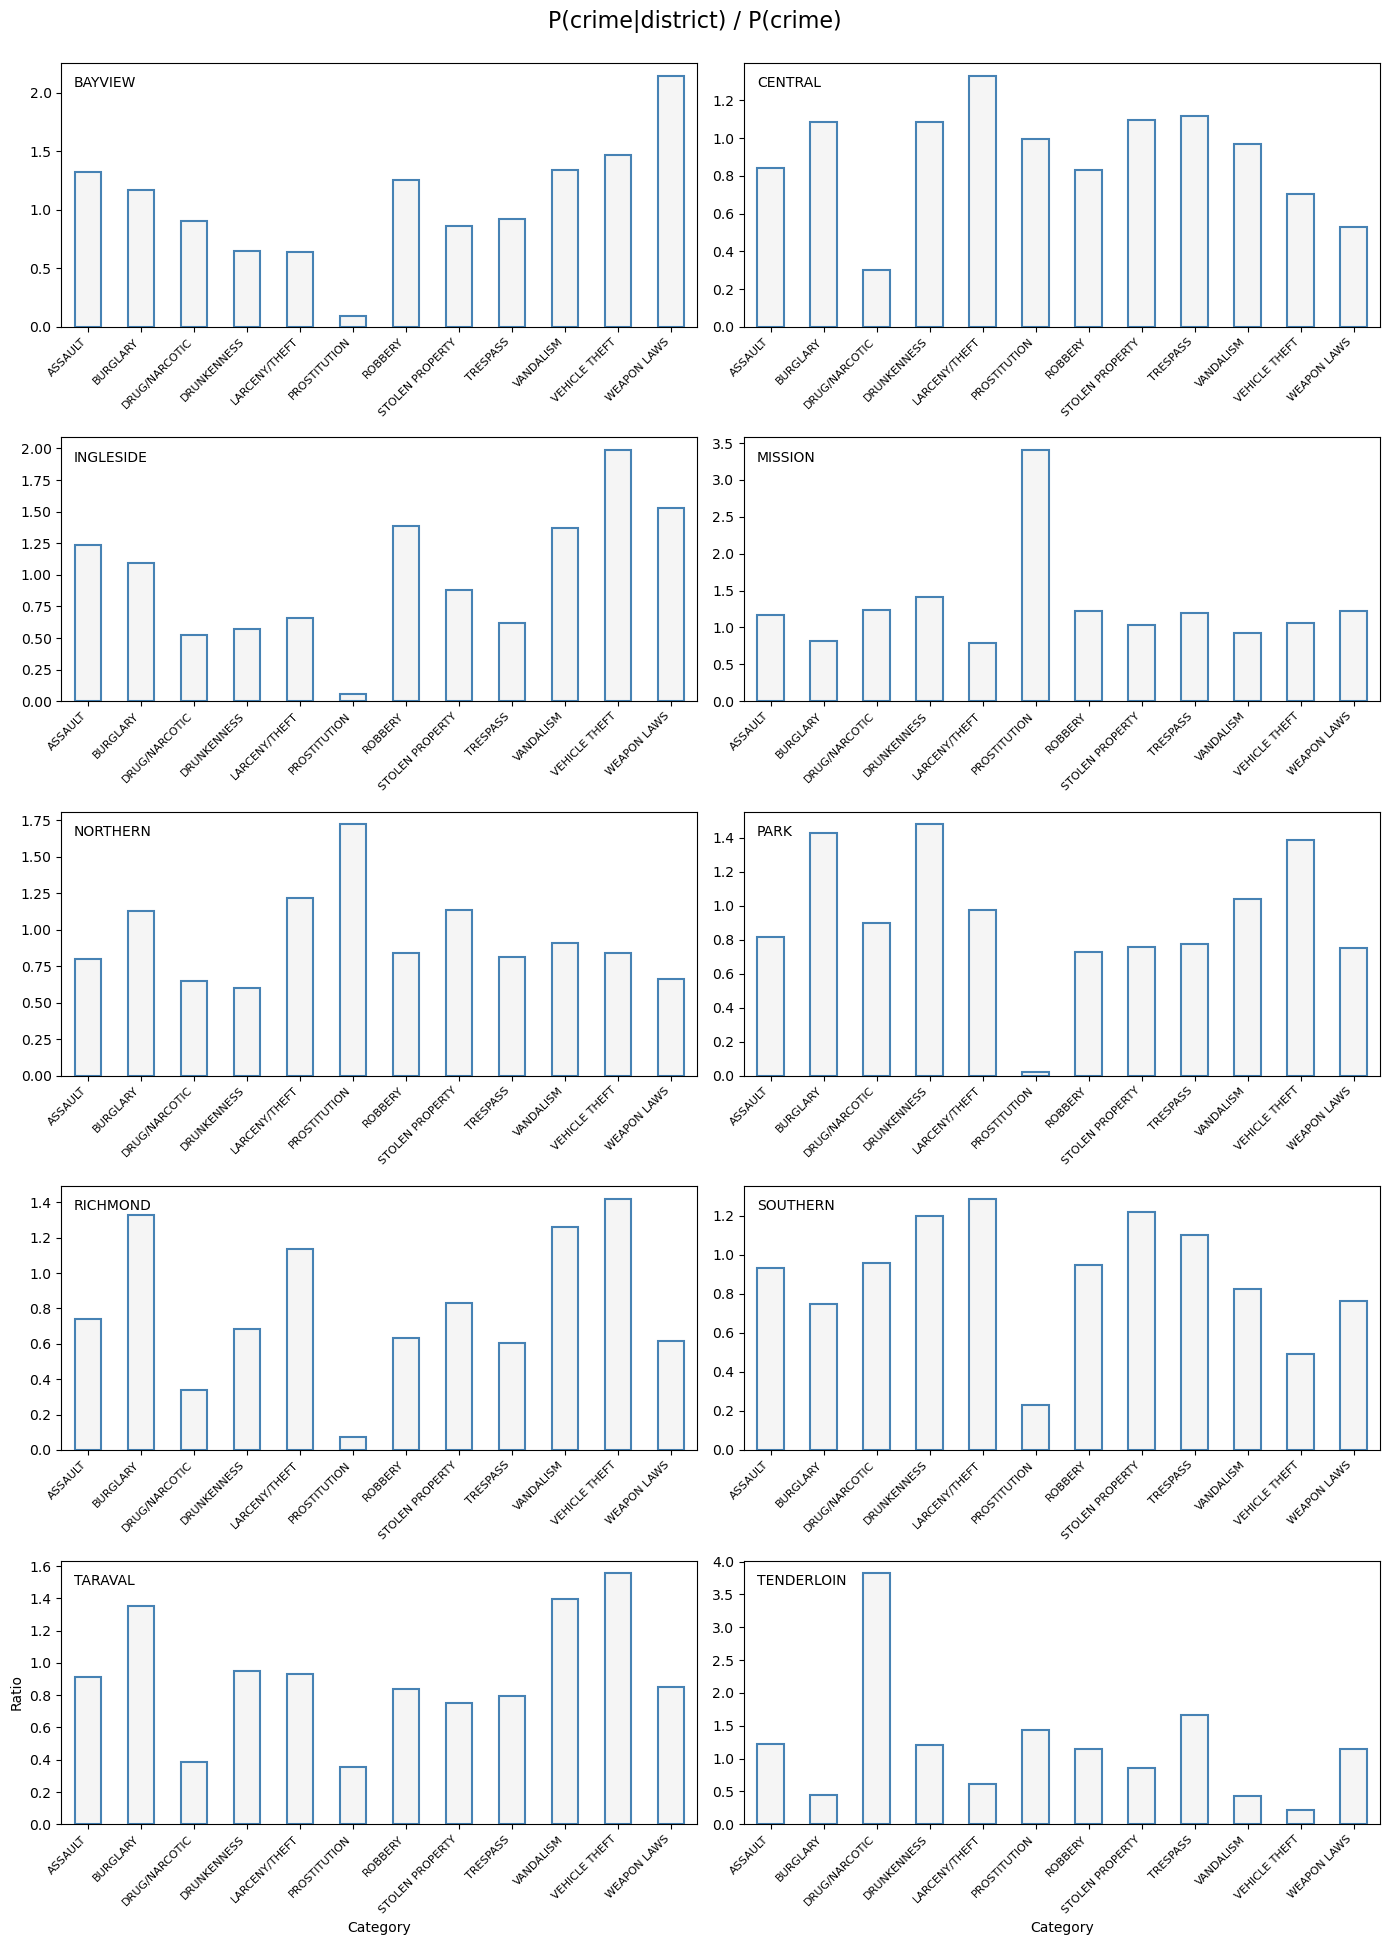

In [93]:
# Step 1: Filter the dataset to include only the focus crimes
focus_crimes = set(['WEAPON LAWS', 'PROSTITUTION', 'ROBBERY', 'BURGLARY', 'ASSAULT', 
                    'DRUNKENNESS', 'DRUG/NARCOTIC', 'TRESPASS', 'LARCENY/THEFT', 
                    'VANDALISM', 'VEHICLE THEFT', 'STOLEN PROPERTY'])

# Filter the dataframe to only include rows with the focus crimes
cleaned_df_focus = cleaned_df[cleaned_df['Incident Category'].isin(focus_crimes)]

# Step 2: Calculate P(crime) - Overall probability of each focus crime
crime_counts = cleaned_df_focus['Incident Category'].value_counts(normalize=True)

# Step 3: Calculate P(crime | district) - Probability of each crime for each district
district_crime_counts = cleaned_df_focus.groupby(['Police District', 'Incident Category']).size().unstack()
district_crime_probs = district_crime_counts.div(district_crime_counts.sum(axis=1), axis=0)

# Step 4: Calculate the ratio P(crime | district) / P(crime)
crime_ratio = district_crime_probs.div(crime_counts, axis=1)

# Step 5: Calculate the number of rows needed for the subplots
num_districts = len(crime_ratio.index)
ncols = 2  # Fixed number of columns
nrows = (num_districts + ncols - 1) // ncols  # Dynamic number of rows based on the number of districts

# Step 6: Create the subplots with the dynamic grid size
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, 4*nrows))  # Adjust figure size for dynamic layout
axes = axes.flatten()

# Loop through each district and plot the ratio
districts = crime_ratio.index

for ax, district in zip(axes, districts):
    crime_ratio.loc[district].plot(
        kind='bar', ax=ax, color='whitesmoke', edgecolor='steelblue', width=0.5, linewidth=1.5
    )

    ax.set_ylabel('Ratio', fontsize=10)
    ax.set_xticklabels(crime_ratio.columns, rotation=45, ha='right', fontsize=8)  # Adjust label rotation

    # Remove x-labels and y-labels as needed
    ax.set_xlabel("")  # Remove the x-axis labels
    if ax != axes[-ncols]:  # Keep y-labels only on the last column
        ax.set_ylabel("")

    # Adjust position of text to ensure it doesn't overlap with bars
    ax.text(
        0.02, 0.95, district, fontsize=10, ha="left", va="top", transform=ax.transAxes, fontweight="normal"
    )

# Set the common x-axis label 'Category' only for the bottom subplots
for ax in axes[-ncols:]:
    ax.set_xlabel('Category', fontsize=10)

# Add a main title for the figure
fig.suptitle("P(crime|district) / P(crime)", fontsize=16, y=1)

# Adjust layout to prevent overlapping of labels
plt.tight_layout(rect=[0, 0.03, 1, 1])  # Adjust spacing for **better fit**
plt.show()